<a href="https://colab.research.google.com/github/andreiamferreira/sinais/blob/main/Anotacoes_revisao_prova_pratica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```
Questão 1
a) Plote os sinais x(3n) e h(n+2). Quais transformações os x(n) e h(n) sofreram, respectivamente?
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([3, 11, 7, 0, -1, 4, 2])  # valores de x
h = np.array([2, 3, 0, -5, 2, 1])   #

n_x = np.arange(-3, 4) # indices de x -> vai de -3 até 4, mas 4 não é incluido -> índices [−3,−2,−1,0,1,2,3].
n_h = np.arange(-1, 5)

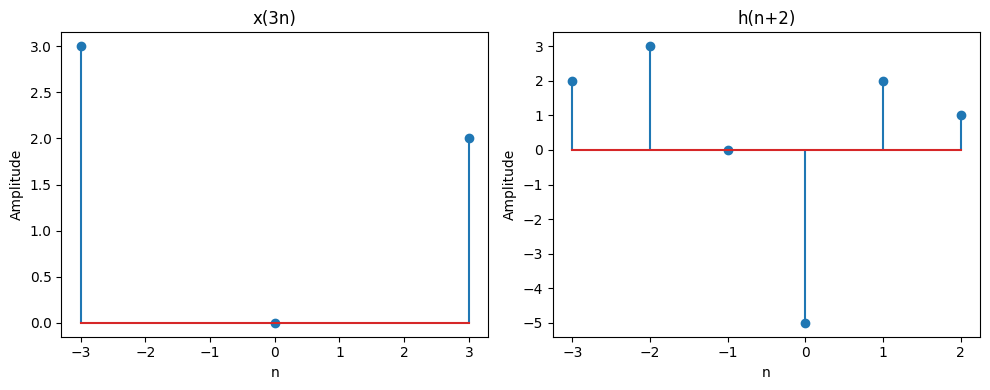

In [ ]:
# sinal x(3n) é comprimido temporalmente em um fator de 3 -> valores de x(n) em índices multiplos de 3 serão considerados

n_x_3n = n_x[::3] # indices de x que sao multiplos de 3
x_3n = x[::3] # seleciona os valores correspondentes em x

# se fosse expansao n_x = np.arange(-3, 4)
# x = np.array([3, 11, 7, 0, -1, 4, 2])

# k = 2  # Fator de expansão
# n_x_exp = n_x * k  # Índices expandidos
# x_exp = np.zeros((n_x_exp[-1] - n_x_exp[0] + 1,))  # Sinal expandido com zeros
# x_exp[::k] = x  # Insere valores originais nos índices expandidos

n_h_n2 = n_h - 2 # h (n + 2) -> sinal é deslocado no tempo por -2 -> reduz em 2 unidades
# n_h - 2 aplica esse deslocamento nos indeices
# valores das amostras permanecem os mesmos

#caso fosse h(n-2), deslocaria para a direita, incrementando + 2 unidades
# n_h_n2 = n_h + 2

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.stem(n_x_3n, x_3n)
plt.title('x(3n)')
plt.xlabel('n')
plt.ylabel('Amplitude')

plt.subplot(1, 2, 2)
plt.stem(n_h_n2, h)
plt.title('h(n+2)')
plt.xlabel('n')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()



```
b) Calcule a convolução entre x(3n) e h(n+2). Plote o resultado.
```



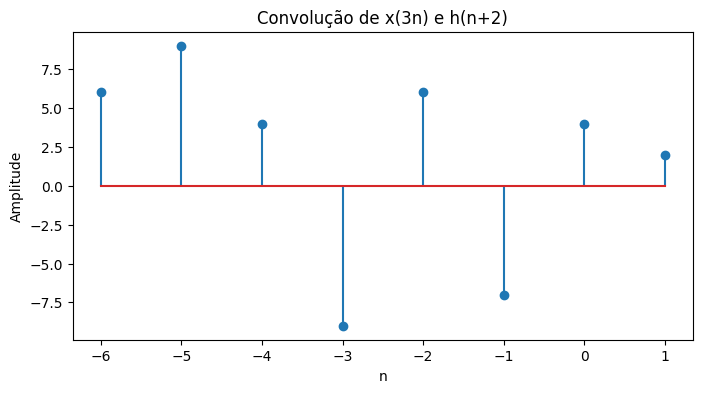

In [ ]:
conv_result = np.convolve(x_3n, h)

n_conv = np.arange(n_x_3n[0] + n_h_n2[0], n_x_3n[0] + n_h_n2[0] + len(conv_result))

plt.figure(figsize=(8, 4))
plt.stem(n_conv, conv_result)
plt.title('Convolução de x(3n) e h(n+2)')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.show()



```
c) Calcule a transformada discreta de Fourier (TDF) do resultado da convolução entre x(3n) e h(n+2). Qual o valor DC deste sinal?
```



In [ ]:
conv_result_fft = np.fft.fft(conv_result)

valor_dc = np.real(conv_result_fft[0])

print(f'O valor DC do sinal é: {valor_dc}')

O valor DC do sinal é: 15.0




```
d) Plote os gráficos de (magnitude x frequência) e (fase x frequência) do sinal com os dados calculados a partir da letra C.
Suponha para isso que a frequência de Nyquist dos sinais seja de 30 Hz.

```



In [ ]:
# caso precise de nyquist
# Considerando o teorema de Nyquist, qual dever ser a taxa de amostragem para este sinal cos(4pit)? Amostre o sinal x(t) utilizando a taxa de amostragem de Nyquist e plote. Comente o resultado. Lembrar que: x[n] = x[nTs] = cos[2pifonTs], ou seja, t = n.Ts!

#Frequencia do sinal a ser amostrado:
f0 = 2

#Período de amostragem (intervalo de tempo entre duas amostras).
ts = 1/(1*f0)

#Número de amostras no gráfico:
t = np.arange(0,1+ts,ts)

# variando de zero até a última amostra a ser lida.
n = np.arange(0,len(t))

#Expandindo o argumento para uma lista de 2*pi*Ts para cada n.

x = np.cos(2*np.pi*f0*n*ts)

#Plotando os resultados:

plt.figure(figsize=(10,5))
plt.grid("on")
plt.title("Amostrando na frequência do sinal")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.stem(t, x, 'b',use_line_collection=True)
plt.plot(t, x, '-o')


# largura de banda é o tamanho do sinal que vai do minimo ao maximo


f0 = 2
ts = 1/(2*f0)
t = np.arange(0,1+ts,ts)
n = np.arange(0,len(t))
x = np.cos(2*np.pi*f0*n*ts)
plt.figure(figsize=(10,5))
plt.grid("on")
plt.title("Amostrando em 2 vezes a frequência do sinal")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.stem(t, x, 'b',use_line_collection=True)
plt.plot(t, x, '-o')
# aaaaaaaaaaaaaaa
# Sinal amostrado: soma de senos com frequências 50 Hz e 150 Hz
fs = 1000  # Taxa de amostragem em Hz
t = np.linspace(0, 1, fs, endpoint=False)  # Intervalo de tempo de 1 segundo
signal = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 150 * t)

# Calcular a frequência de Nyquist
f_nyquist, f_max = calculate_nyquist(signal, fs)

print(f"Frequência máxima detectada: {f_max:.2f} Hz")
print(f"Frequência de Nyquist: {f_nyquist:.2f} Hz")

# Plotar o espectro do sinal
frequencies = fftfreq(len(signal), d=1/fs)
magnitude = np.abs(fft(signal))

plt.plot(np.abs(frequencies), magnitude)
plt.title("Espectro de Frequência do Sinal")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()



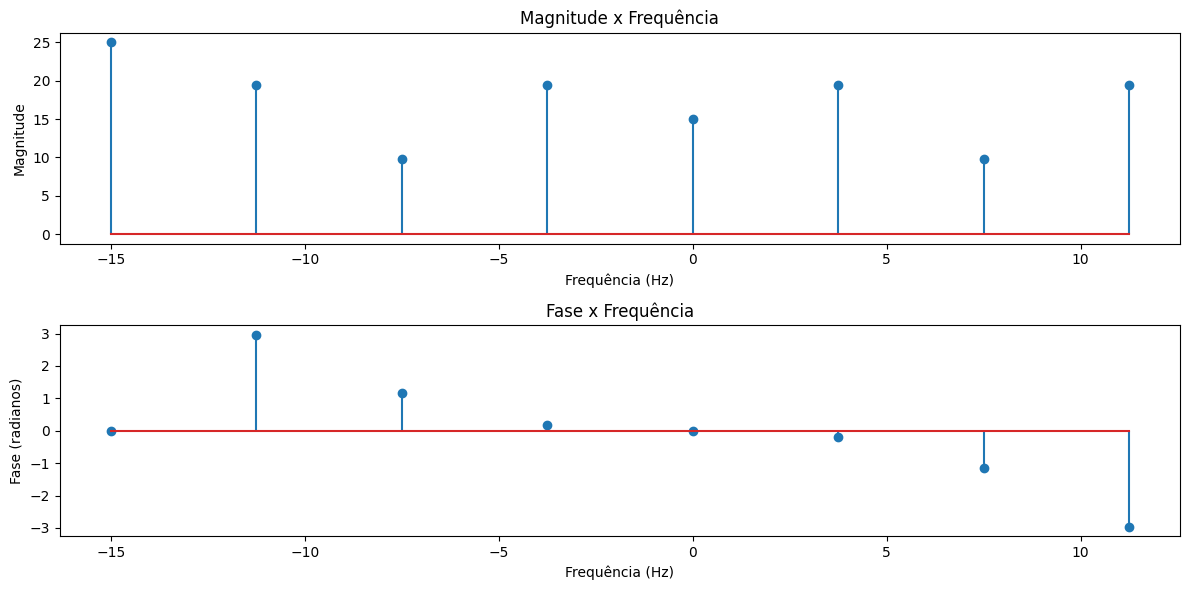

In [ ]:
nyquist_freq = 30

freqs = np.fft.fftfreq(len(conv_result), d=1/nyquist_freq)

magnitude = np.abs(conv_result_fft)
fase = np.angle(conv_result_fft)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.stem(freqs, magnitude)
plt.title('Magnitude x Frequência')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')

plt.subplot(2, 1, 2)
plt.stem(freqs, fase)
plt.title('Fase x Frequência')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (radianos)')

plt.tight_layout()
plt.show()



```
Questão 2
a) Plote o espectro de Fourier deste sinal.

```



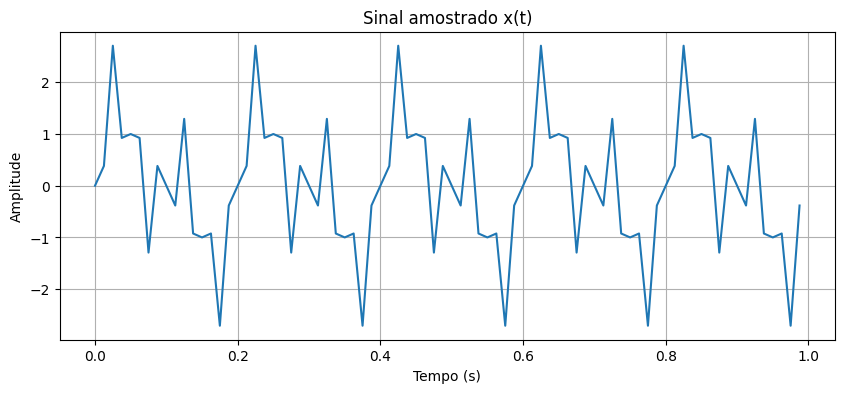

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fs = 80
T = 1 / fs
t = np.arange(0, 1, T)

x_t = np.sin(10 * np.pi * t) + np.sin(20 * np.pi * t) + np.sin(100 * np.pi * t) + np.sin(400 * np.pi * t)

plt.figure(figsize=(10, 4))
plt.plot(t, x_t)
plt.title('Sinal amostrado x(t)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

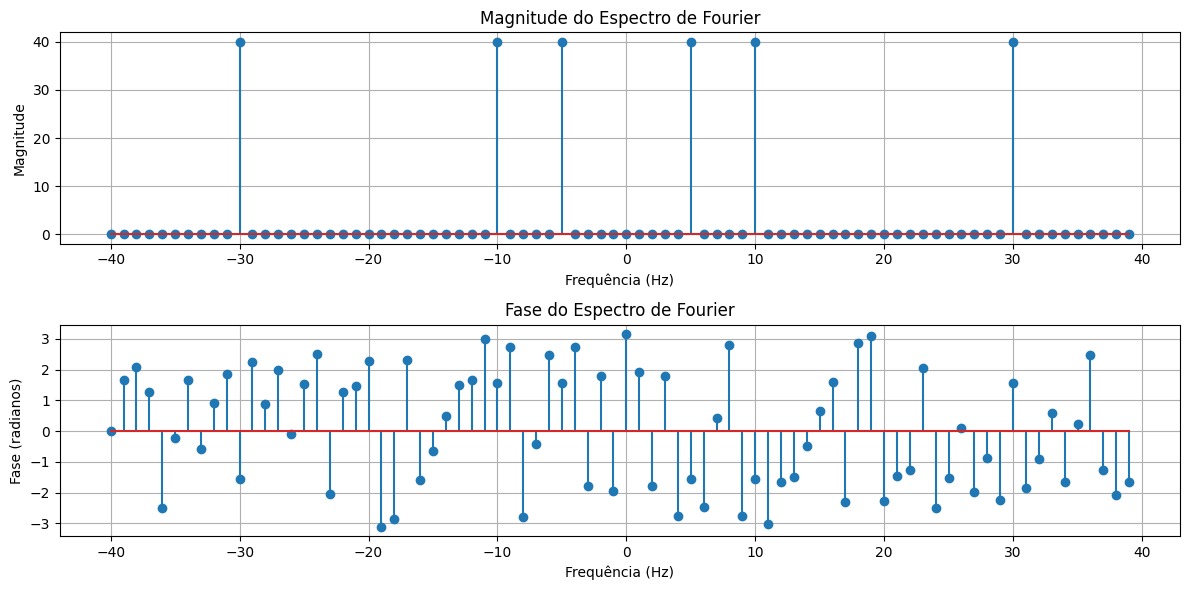

In [ ]:
X_f = np.fft.fft(x_t)
freqs = np.fft.fftfreq(len(X_f), T)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.stem(freqs, np.abs(X_f))
plt.title('Magnitude do Espectro de Fourier')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(freqs, np.angle(X_f))
plt.title('Fase do Espectro de Fourier')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (radianos)')
plt.grid(True)

plt.tight_layout()
plt.show()



```
b) Quais frequências, de acordo com o espectro plotado em a, sofreram aliasing?
Quais foram amostradas corretamente?
```



A frequência de Nyquist é a metade da taxa de amostragem, ou seja, 40 Hz. No sinal contínuo estão presentes as frequências de 5 Hz, 10 Hz, 50 Hz e 200 Hz. As frequências que são menores que 40 Hz são corretamente captadas durante a amostragem. Porém, qualquer frequência acima de 40 Hz sofrerá o efeito do aliasing, sendo duplicada e refletida dentro do intervalo de 0 a 40 Hz. Desta forma, as frequências de 50 Hz e 200 Hz irão se misturar e aparecer como frequências incorretas no espectro devido ao aliasing, enquanto as frequências de 5 Hz e 10Hz serão corretamente amostradas.



```
c) Faça o ajuste da taxa de amostragem para que o sinal possa ser plotado sem a presença do aliasing.
Plote novamente o gráfico, mostrando que ajuste está adequado e que todas as frequências foram amostradas corretamente.
```



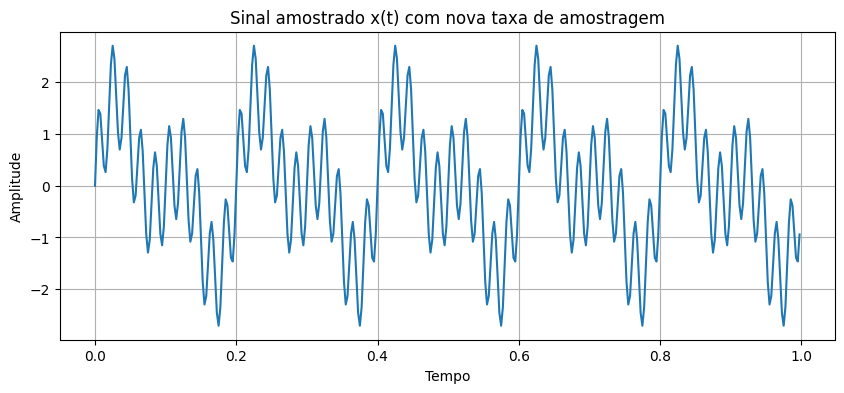

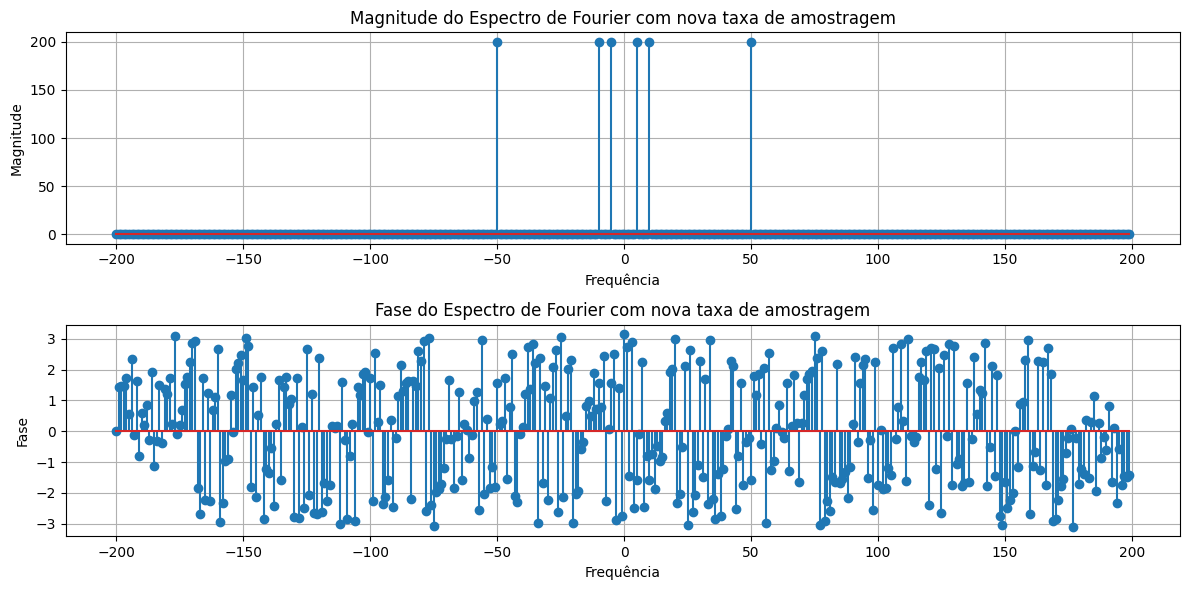

In [ ]:
fs_new = 400
T_new = 1 / fs_new
t_new = np.arange(0, 1, T_new)

x_t_new = np.sin(10 * np.pi * t_new) + np.sin(20 * np.pi * t_new) + np.sin(100 * np.pi * t_new) + np.sin(400 * np.pi * t_new)

plt.figure(figsize=(10, 4))
plt.plot(t_new, x_t_new)
plt.title('Sinal amostrado x(t) com nova taxa de amostragem')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

X_f_new = np.fft.fft(x_t_new)
freqs_new = np.fft.fftfreq(len(X_f_new), T_new)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.stem(freqs_new, np.abs(X_f_new))
plt.title('Magnitude do Espectro de Fourier com nova taxa de amostragem')
plt.xlabel('Frequência')
plt.ylabel('Magnitude')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(freqs_new, np.angle(X_f_new))
plt.title('Fase do Espectro de Fourier com nova taxa de amostragem')
plt.xlabel('Frequência')
plt.ylabel('Fase')
plt.grid(True)

plt.tight_layout()
plt.show()